# Import Libraries

In [51]:
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Set visual style
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

# Data Loading & Initial Cleaning

In [52]:
# Load the dataset
df = pd.read_csv('biased_leukemia_dataset.csv')

# Clean WBC Count (removing absolute negatives if present)
df['WBC_Count'] = df['WBC_Count'].abs()

# Map Target to Numbers
df['Leukemia_Status_Num'] = df['Leukemia_Status'].map({'Negative': 0, 'Positive': 1})

# Define our 6 core features
features = ['Age', 'WBC_Count', 'RBC_Count', 'Platelet_Count', 'Hemoglobin_Level', 'BMI']

print("Dataset Loaded. Shape:", df.shape)
df.head()

Dataset Loaded. Shape: (143194, 23)


,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,...,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status,Leukemia_Status_Num
0,1,52,Male,China,2698,5.36,262493,12.2,72,Yes,...,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative,0
1,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,...,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive,1
2,3,72,Male,France,9614,5.17,319600,13.4,94,No,...,No,No,27.7,No,No,Ethnic_Group_B,Low,Urban,Negative,0
3,4,61,Male,Brazil,6278,5.41,215200,11.6,50,No,...,No,No,31.6,No,No,Ethnic_Group_A,Medium,Rural,Negative,0
4,5,21,Male,Brazil,8342,4.78,309169,14.3,28,No,...,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative,0


# Exploratory Data Analysis (EDA)

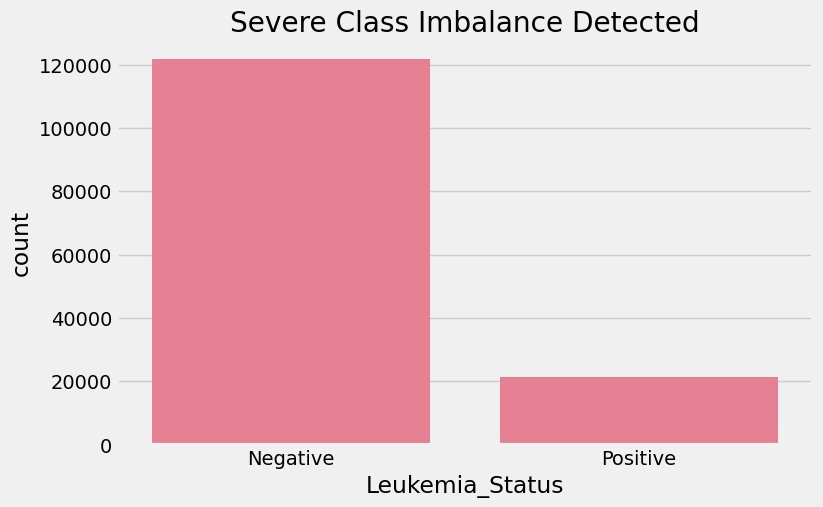

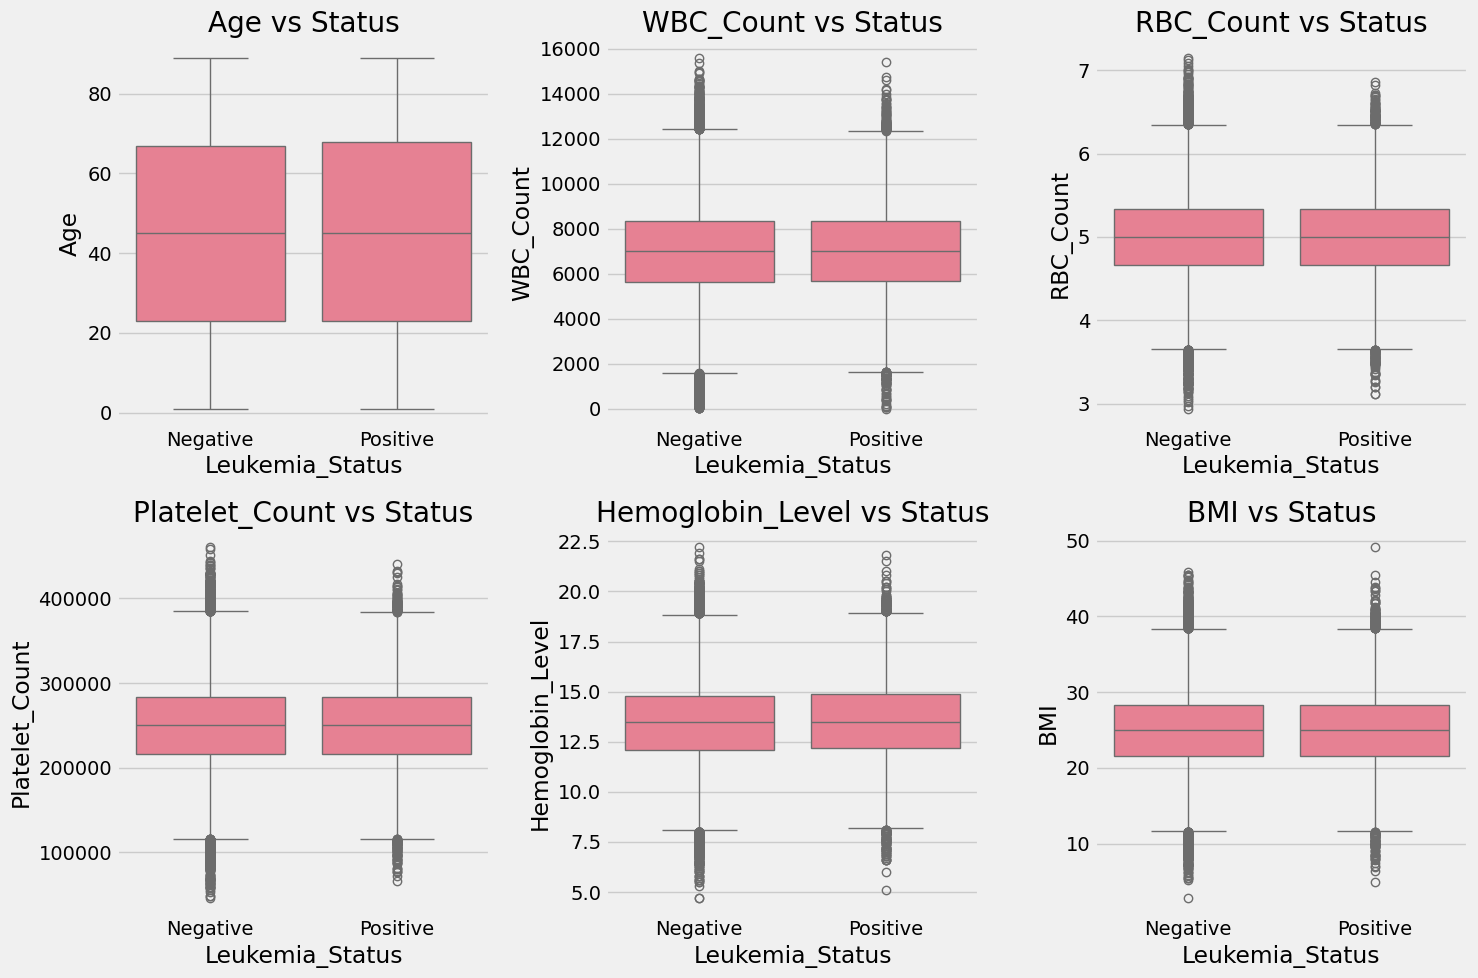

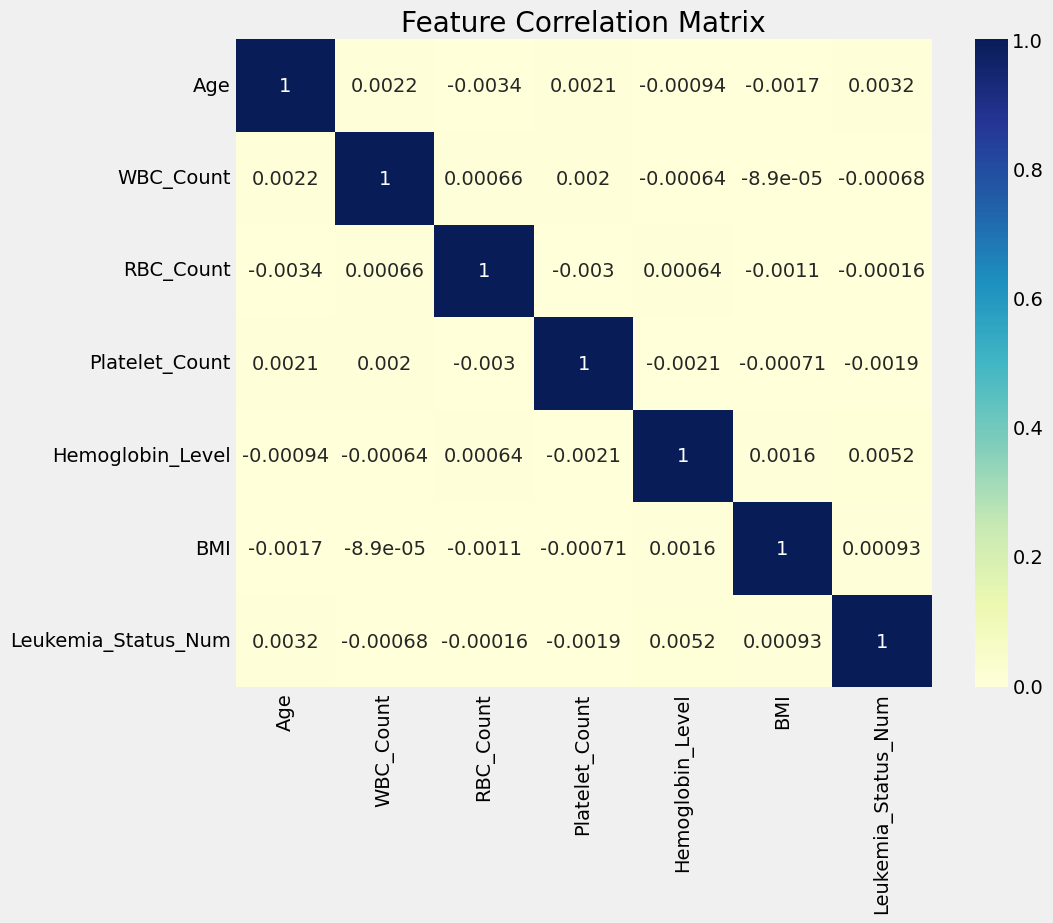

In [53]:
# 1. Distribution of Target Class
plt.figure(figsize=(8, 5))
sns.countplot(x='Leukemia_Status', data=df)
plt.title('Severe Class Imbalance Detected')
plt.show()

# 2. Box Plots for Feature Analysis
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Leukemia_Status', y=col, data=df)
    plt.title(f'{col} vs Status')
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ['Leukemia_Status_Num']].corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Matrix')
plt.show()

# SMOTE & Balancing

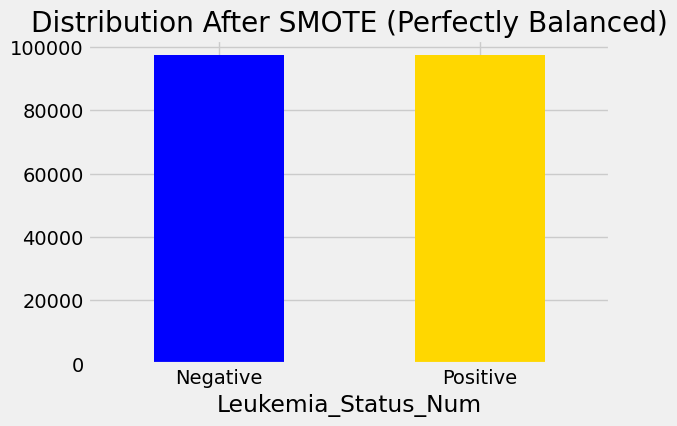

In [54]:
# Select Features and Target
X = df[features]
y = df['Leukemia_Status_Num']

# Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualize the fix
plt.figure(figsize=(6, 4))
pd.Series(y_train_res).value_counts().plot(kind='bar', color=['blue', 'gold'])
plt.title('Distribution After SMOTE (Perfectly Balanced)')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()

# Scaling & Professional Training

In [55]:
# Initialize Scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train_res)

# ONLY transform test data (to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

# Train the Random Forest
# We use n_estimators=100 for a solid professional baseline
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train_res)

print("Model Training with Balanced Data Complete.")

Model Training with Balanced Data Complete.


# Model Evaluation (The Proof)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.86     24360
           1       0.15      0.14      0.14      4279

    accuracy                           0.75     28639
   macro avg       0.50      0.50      0.50     28639
weighted avg       0.75      0.75      0.75     28639



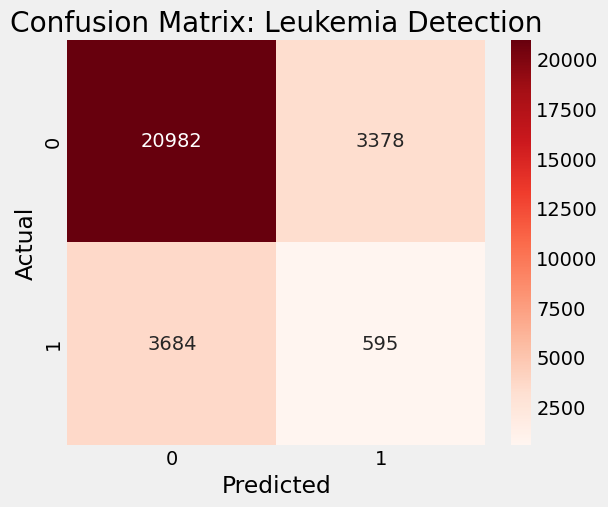

In [56]:
y_pred = model.predict(X_test_scaled)

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Leukemia Detection')
plt.show()

# Feature Importance & Export

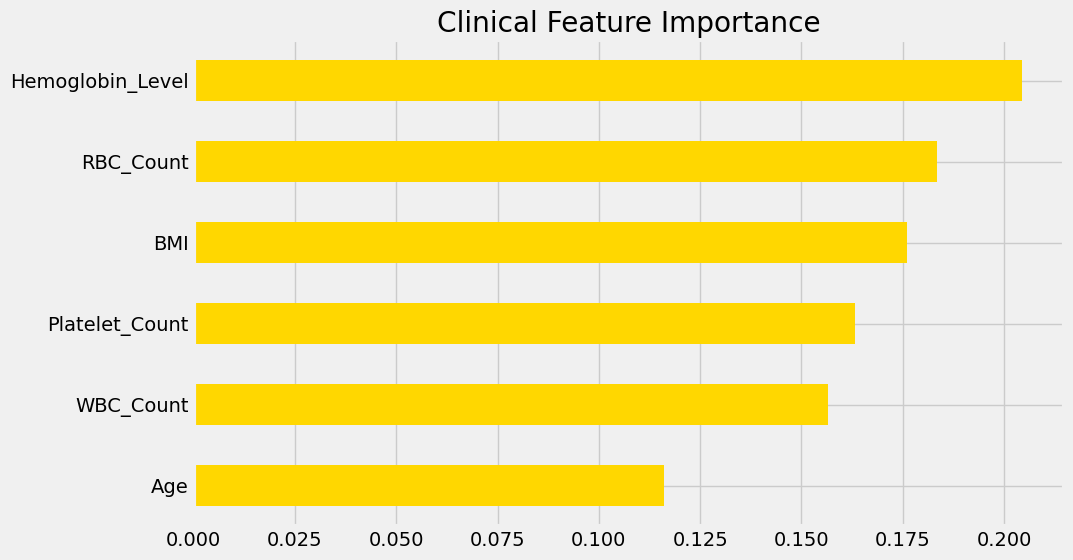

Files saved successfully! Download 'leukemia_model.pkl' and 'scaler.pkl' now.


In [57]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='gold')
plt.title('Clinical Feature Importance')
plt.show()

# Export for Flask App
joblib.dump(model, 'leukemia_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Files saved successfully! Download 'leukemia_model.pkl' and 'scaler.pkl' now.")